In [1]:
!pip install -q "transformers==4.46.3" "datasets>=2.20" "peft>=0.13" "accelerate>=1.0" "seqeval" "evaluate" "scikit-learn" "matplotlib"
!pip install -U torchao
!pip install boto3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.9 MB/s eta 0:00:00


In [5]:
import json
import os
import shutil
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import boto3
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from google.colab import userdata
from datasets import Dataset, DatasetDict
from peft import LoraConfig, TaskType, get_peft_model
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1
from seqeval.metrics import precision_score as seq_p
from seqeval.metrics import recall_score as seq_r
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load Secrets from Google Colab
AWS_ACCESS_KEY = userdata.get('AWS_ACCESS_KEY')
AWS_SECRET_KEY = userdata.get('AWS_SECRET_KEY')
BUCKET_NAME = userdata.get('S3_BUCKET_NAME')

# Path to the dataset file downloaded from Kaggle.
DATA_PATH = kagglehub.dataset_download("yashpwrr/resume-ner-training-dataset") + "/train.json"

MODEL_NAME = "bert-base-cased"

OUTPUT_DIR = "resume-ner-lora"
MAX_LEN = 384
BATCH_SIZE = 8
EPOCHS = 6
LR = 2e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Labels we actually want. Everything else gets dropped.
KEEP_LABELS = [
    "PERSON",
    "EMAIL",
    "DESIGNATION",
    "EDUCATION",
    "LOCATION"
]

100%|██████████| 14.2M/14.2M [00:00<00:00, 66.7MB/s]

Extracting files...


In [6]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

print(f"Loaded {len(raw)} samples")
print("Sample keys:", list(raw[0].keys()))
print("Example annotations:", raw[0]["annotations"][:3])

Loaded 5960 samples
Sample keys: ['text', 'annotations']
Example annotations: [[1296, 1622, 'SKILL'], [993, 1154, 'SKILL'], [939, 957, 'PERSON']]


In [7]:
label_counts = Counter()
for ex in raw:
    for ann in ex["annotations"]:
        # Each annotation is [start, end, label]
        if len(ann) >= 3:
            label_counts[ann[2]] += 1

print("Label distribution in raw data:")
for lbl, cnt in label_counts.most_common():
    keep = "KEEP" if lbl in KEEP_LABELS else "drop"
    print(f"  {lbl:15s} {cnt:>8d}  [{keep}]")

Label distribution in raw data:
  SKILL             549465  [drop]
  OTHER              10267  [drop]
  DESIGNATION         4301  [KEEP]
  LOCATION            4073  [KEEP]
  EXPERIENCE          3544  [drop]
  PERSON              3122  [KEEP]
  EDUCATION           2124  [KEEP]
  EXPERTISE           1045  [drop]
  EMAIL                815  [KEEP]
  COMPANY              218  [drop]
  COLLABORATION        187  [drop]
  LANGUAGE             159  [drop]
  ACTION               133  [drop]
  CERTIFICATION        122  [drop]


In [8]:
def clean_annotations(text, anns):
    cleaned = []
    for ann in anns:
        if len(ann) < 3:
            continue
        start, end, label = ann[0], ann[1], ann[2]
        if label not in KEEP_LABELS:
            continue
        if not (0 <= start < end <= len(text)):
            continue
        span = text[start:end]

        lead = len(span) - len(span.lstrip())
        trail = len(span) - len(span.rstrip())
        new_start = start + lead
        new_end = end - trail
        if new_end <= new_start:
            continue
        cleaned.append((new_start, new_end, label))

    cleaned.sort(key=lambda x: (x[1] - x[0]), reverse=True)
    accepted = []
    for s, e, l in cleaned:
        overlap = any(not (e <= a_s or s >= a_e) for a_s, a_e, _ in accepted)
        if not overlap:
            accepted.append((s, e, l))
    accepted.sort(key=lambda x: x[0])
    return accepted

cleaned_data = []
for ex in raw:
    text = ex["text"]
    anns = clean_annotations(text, ex["annotations"])
    if not anns:
        continue
    cleaned_data.append({"text": text, "spans": anns})

print(f"Kept {len(cleaned_data)} / {len(raw)} documents after cleaning")

Kept 988 / 5960 documents after cleaning


In [9]:
label_counts = Counter()
for ex in cleaned_data:
    for _, _, lbl in ex["spans"]:
        label_counts[lbl] += 1

print("Entity counts after filtering:")
for lbl, n in label_counts.most_common():
    print(f"  {lbl:<15} {n}")

Entity counts after filtering:
  DESIGNATION     4293
  LOCATION        4069
  PERSON          3118
  EDUCATION       2119
  EMAIL           815


In [10]:
LABEL_LIST = ["O"]
for lbl in sorted(KEEP_LABELS):
    LABEL_LIST.append(f"B-{lbl}")
    LABEL_LIST.append(f"I-{lbl}")
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
print(f"{len(LABEL_LIST)} BIO labels")

11 BIO labels


In [11]:
train_data, test_data = train_test_split(
    cleaned_data, test_size=0.10, random_state=SEED
)
train_data, val_data = train_test_split(
    train_data, test_size=0.10, random_state=SEED
)
print(f"Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")

Train: 800  Val: 89  Test: 99


In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def encode_example(example):
    text = example["text"]

    text = text.encode("utf-8", errors="ignore").decode("utf-8")

    spans = example["spans"]

    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
    )
    offsets = enc.pop("offset_mapping")
    special = enc.pop("special_tokens_mask")

    labels = []
    span_idx = 0
    inside_span = None
    for (tok_start, tok_end), is_special in zip(offsets, special):
        if is_special or tok_start == tok_end:
            labels.append(-100)
            continue

        while span_idx < len(spans) and spans[span_idx][1] <= tok_start:
            span_idx += 1

        assigned = False
        if span_idx < len(spans):
            s, e, lbl = spans[span_idx]
            if tok_end > s and tok_start < e:
                if inside_span != (s, e, lbl):
                    labels.append(LABEL2ID[f"B-{lbl}"])
                    inside_span = (s, e, lbl)
                else:
                    labels.append(LABEL2ID[f"I-{lbl}"])
                assigned = True
        if not assigned:
            labels.append(LABEL2ID["O"])
            inside_span = None

    enc["labels"] = labels
    return enc


def to_hf_dataset(rows):
    return Dataset.from_list([encode_example(r) for r in rows])


train_ds = to_hf_dataset(train_data)
val_ds = to_hf_dataset(val_data)
test_ds = to_hf_dataset(test_data)

dsd = DatasetDict(train=train_ds, validation=val_ds, test=test_ds)
print(dsd)


_sample = train_ds[0]
_tokens = tokenizer.convert_ids_to_tokens(_sample["input_ids"])
print(f"{'TOKEN':<20s} {'LABEL'}")
print("-" * 40)
for tok, lid in zip(_tokens[:80], _sample["labels"][:80]):
    lbl = ID2LABEL[lid] if lid != -100 else "IGN"
    print(f"{tok:<20s} {lbl}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 89
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 99
    })
})
TOKEN                LABEL
----------------------------------------
[CLS]                IGN
"                    O
j                    O
##H                  O
Joseph               B-PERSON
C                    I-PERSON
.                    I-PERSON
Herr                 I-PERSON
##on                 I-PERSON
Senior               B-DESIGNATION
U                    I-DESIGNATION
##X                  I-DESIGNATION
,                    I-DESIGNATION
U                    I-DESIGNATION
##I                  I-DESIGNATION
and                  I-DESIGNATION
Visual               I-DESIGNATION
De

In [13]:
base_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_LIST),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

lora_cfg = LoraConfig(
    task_type=TaskType.TOKEN_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "key", "value",
                    "query_proj", "key_proj", "value_proj"],
    modules_to_save=["classifier"],
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 893,195 || all params: 108,621,334 || trainable%: 0.8223


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_seq, pred_seq = [], []
    for p_row, l_row in zip(preds, labels):
        t, pr = [], []
        for p_id, l_id in zip(p_row, l_row):
            if l_id == -100:
                continue
            t.append(ID2LABEL[int(l_id)])
            pr.append(ID2LABEL[int(p_id)])
        true_seq.append(t)
        pred_seq.append(pr)

    return {
        "precision": seq_p(true_seq, pred_seq),
        "recall": seq_r(true_seq, pred_seq),
        "f1": seq_f1(true_seq, pred_seq),
    }

In [15]:
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=False,
    bf16=False,
    max_grad_norm=1.0,
    gradient_checkpointing=True,
    seed=SEED,
)

model.enable_input_require_grads()

collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dsd["train"],
    eval_dataset=dsd["validation"],
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)


In [16]:
baseline_metrics = trainer.evaluate(dsd["test"])
print("BASELINE (pre-fine-tune) test metrics:", baseline_metrics)

BASELINE (pre-fine-tune) test metrics: {'eval_loss': 2.4424216747283936, 'eval_model_preparation_time': 0.0057, 'eval_precision': 0.0006030243992949253, 'eval_recall': 0.016352201257861635, 'eval_f1': 0.0011631548338030691, 'eval_runtime': 3.4019, 'eval_samples_per_second': 29.101, 'eval_steps_per_second': 2.058}


In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Precision,Recall,F1
1,0.470000,0.378971,0.005700,0.068921,0.068653,0.068787
2,0.244100,0.231284,0.005700,0.263626,0.306995,0.283662
3,0.220300,0.195738,0.005700,0.355088,0.415803,0.383055
4,0.196200,0.184026,0.005700,0.380000,0.492228,0.428894
5,0.177600,0.179039,0.005700,0.388060,0.505181,0.438942
6,0.167900,0.178549,0.005700,0.392315,0.502591,0.440659


TrainOutput(global_step=600, training_loss=0.3628593810399373, metrics={'train_runtime': 426.7903, 'train_samples_per_second': 11.247, 'train_steps_per_second': 1.406, 'total_flos': 950622887116800.0, 'train_loss': 0.3628593810399373, 'epoch': 6.0})

In [18]:
finetuned_metrics = trainer.evaluate(dsd["test"])
print("FINE-TUNED test metrics:", finetuned_metrics)

# Per-entity classification report
preds_out = trainer.predict(dsd["test"])
preds = np.argmax(preds_out.predictions, axis=-1)
labels = preds_out.label_ids

true_seq, pred_seq = [], []
for p_row, l_row in zip(preds, labels):
    t, pr = [], []
    for p_id, l_id in zip(p_row, l_row):
        if l_id == -100:
            continue
        t.append(ID2LABEL[int(l_id)])
        pr.append(ID2LABEL[int(p_id)])
    true_seq.append(t)
    pred_seq.append(pr)

print(seq_report(true_seq, pred_seq, digits=4))

FINE-TUNED test metrics: {'eval_loss': 0.18818919360637665, 'eval_model_preparation_time': 0.0057, 'eval_precision': 0.3829174664107486, 'eval_recall': 0.5018867924528302, 'eval_f1': 0.4344039194338596, 'eval_runtime': 2.7967, 'eval_samples_per_second': 35.399, 'eval_steps_per_second': 2.503, 'epoch': 6.0}
              precision    recall  f1-score   support

 DESIGNATION     0.3615    0.5144    0.4246       208
   EDUCATION     0.3830    0.4655    0.4202       116
       EMAIL     0.7711    0.9552    0.8533        67
    LOCATION     0.3147    0.3575    0.3347       221
      PERSON     0.3506    0.5191    0.4185       183

   micro avg     0.3829    0.5019    0.4344       795
   macro avg     0.4362    0.5624    0.4903       795
weighted avg     0.3836    0.5019    0.4337       795



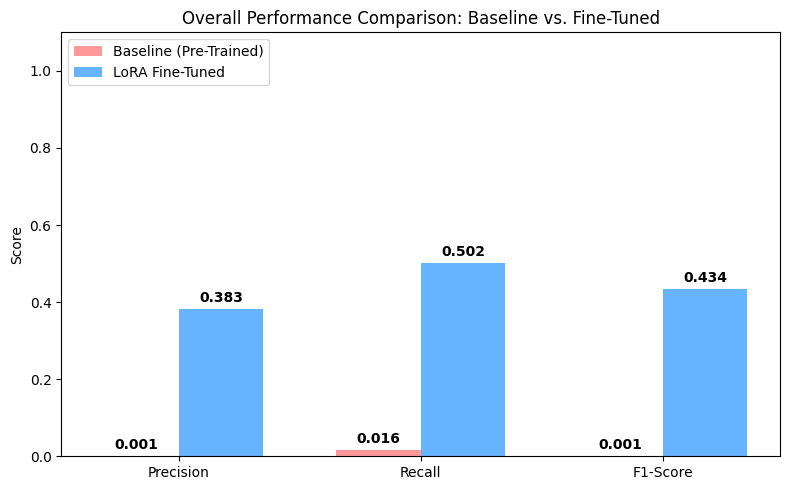

In [19]:
metric_labels = ['Precision', 'Recall', 'F1-Score']

baseline_scores = [
    baseline_metrics.get('eval_precision', 0),
    baseline_metrics.get('eval_recall', 0),
    baseline_metrics.get('eval_f1', 0)
]

finetuned_scores = [
    finetuned_metrics.get('eval_precision', 0),
    finetuned_metrics.get('eval_recall', 0),
    finetuned_metrics.get('eval_f1', 0)
]

# 2. Set up the bar chart positioning
x = np.arange(len(metric_labels))
width = 0.35  # width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (Pre-Trained)', color='#ff9999')
rects2 = ax.bar(x + width/2, finetuned_scores, width, label='LoRA Fine-Tuned', color='#66b3ff')

# 4. Add labels, title, and styling
ax.set_ylabel('Score')
ax.set_title('Overall Performance Comparison: Baseline vs. Fine-Tuned')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)  # Scale from 0 to slightly above 1 for label padding
ax.legend(loc='upper left')

# 5. Function to attach a text label above each bar for exact numbers
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [ ]:
# Keep LoRA adapters separate (smaller, recommended)
model.save_pretrained(f"{OUTPUT_DIR}/adapter")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/adapter")

shutil.make_archive("/content/resume_ner_adapter", "zip", f"{OUTPUT_DIR}/adapter")
print(os.path.getsize("/content/resume_ner_adapter.zip") / 1e6, "MB")

3.631432 MB


In [ ]:
merged = model.merge_and_unload()
merged.save_pretrained(f"{OUTPUT_DIR}/merged")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/merged")

shutil.make_archive("/content/resume_ner_merged", "zip", f"{OUTPUT_DIR}/merged")
print(os.path.getsize("/content/resume_ner_merged.zip") / 1e6, "MB")

print("Uploading to S3...")
s3 = boto3.client(
    's3',
    aws_access_key_id=AWS_ACCESS_KEY,
    aws_secret_access_key=AWS_SECRET_KEY
)
s3.upload_file("/content/resume_ner_merged.zip", BUCKET_NAME, "models/resume_ner_merged.zip")

print("✅ Model successfully uploaded to S3!")

400.266194 MB
Uploading to S3...
✅ Model successfully uploaded to S3!


In [ ]:
adapter_size = sum(os.path.getsize(os.path.join(f"{OUTPUT_DIR}/adapter", f))
                   for f in os.listdir(f"{OUTPUT_DIR}/adapter")) / 1e6
merged_size  = sum(os.path.getsize(os.path.join(f"{OUTPUT_DIR}/merged", f))
                   for f in os.listdir(f"{OUTPUT_DIR}/merged")) / 1e6
print(f"Adapter: {adapter_size:.1f} MB | Merged: {merged_size:.1f} MB | "
      f"LoRA stores {adapter_size/merged_size*100:.1f}% of the model size")

Adapter: 4.5 MB | Merged: 431.8 MB | LoRA stores 1.0% of the model size
